In [1]:
library(tidyverse)
library(car)
library(EBImage)

── Attaching core tidyverse packages ─────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ───────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some



Attaching package: ‘EBImage’


The following object is masked from ‘package:purrr’:

    transpose




### Otsu functions

In [2]:
otsuPlot <- function(nofilmx)
    {
    for(i in 1:ncol(nofilmx)){
        Counts_per_fragment <- nofilmx[nofilmx[,i]> 2,i]

        lcpf <- log(Counts_per_fragment)
        oldRange <- max(lcpf) - min(lcpf)
        newRange <- 2**8 -1
    
        lcpf <- as.integer((lcpf-min(lcpf)) * newRange / oldRange)
        lcpf <- as.matrix(lcpf)
        names(lcpf) <- names(Counts_per_fragment)
        otsufilt <- otsu(lcpf,range = c(0,255), levels = 256)
        densityPlot(lcpf,
                main = c("Upscale to 8 bits from integer values of log(Inter-Peak Distances)", colnames(nofilmx)[i]))
            abline(v = otsufilt )
        
        print(otsufilt)
        
        #densityPlot(lcpf[lcpf <= otsufilt ],
        #        main = c("Upscale to 8 bits from integer values of log(Counts per fragment), OTSU FILTERED", colnames(nofilmx)[i]))
    }
}

otsuFilterDown <- function(nofilmx)
    {
    otsuregions <- c()
    
    for(i in 1:ncol(nofilmx)){
        Counts_per_fragment <- nofilmx[nofilmx[,i]> 2,i]
        print(colnames(nofilmx)[i])

        lcpf <- log(Counts_per_fragment)
        oldRange <- max(lcpf) - min(lcpf)
        newRange <- 2**8 -1
    
        lcpf <- as.integer((lcpf-min(lcpf)) * newRange / oldRange)
        lcpf <- as.matrix(lcpf)
        names(lcpf) <- names(Counts_per_fragment)
        otsufilt <- otsu(lcpf,range = c(0,255), levels = 256)
        
        lcpf <- lcpf[lcpf <= otsufilt]
    
        otsuregions <- c(otsuregions, names(lcpf))
        }
    osturegions <- unique(otsuregions)
    return(otsuregions)
}

otsuFilterUp <- function(nofilmx)
    {
    otsuregions <- c()
    
    for(i in 1:ncol(nofilmx)){
        Counts_per_fragment <- nofilmx[nofilmx[,i]> 2,i]
        print(colnames(nofilmx)[i])

        lcpf <- log(Counts_per_fragment)
        oldRange <- max(lcpf) - min(lcpf)
        newRange <- 2**8 -1
    
        lcpf <- as.integer((lcpf-min(lcpf)) * newRange / oldRange)
        lcpf <- as.matrix(lcpf)
        names(lcpf) <- names(Counts_per_fragment)
        otsufilt <- otsu(lcpf,range = c(0,255), levels = 256)
        
        lcpf <- lcpf[lcpf > otsufilt]
    
        otsuregions <- c(otsuregions, names(lcpf))
        }
    osturegions <- unique(otsuregions)
    return(otsuregions)
}

In [3]:
beds <- list.files("./bienPortadosDeseq_bed_41",full.names = T)[grepl('bed',list.files("./bienPortadosDeseq_bed_41"))]

In [4]:
distances<- data.frame(
  chr=character(),
  dist2NextPeak=numeric(),
  firstPeakID=character(),
  peakSource=character()
)

for (j in 1:length(beds)) {
  bed <- read_tsv(beds[j], col_names=F)
  for( i in 1:(nrow(bed)-1)){
    if (bed$X1[i] == bed$X1[i+1]) {
      onedist <- data.frame(
          chr=bed$X1[i],
          p1start=bed$X2[i],
          p1end=bed$X3[i],
          p2start=bed$X2[i+1],
          p2end=bed$X3[i+1],
          dist2NextPeak=bed$X2[i+1]-bed$X3[i],
          p1id=bed$X4[i],
          p2id=bed$X4[i+1],
          peakSource=beds[j] |> str_remove_all(".bed") |> str_remove("./bienPortadosDeseq_41/")
      )
      distances <- rbind(distances,onedist)
    }
  }
}

distances <- distances |> 
    mutate(log10dist2NextPeak = log10(dist2NextPeak)) |>
    mutate(ip = str_remove(peakSource,'.*_')) |> 
    mutate(class=str_remove(peakSource,"Deseq_.*"))|>
    mutate(p1size=p1end-p1start,
           p2size=p2end-p2start,
           id=make.unique(peakSource)
          )

Rows: 1100 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 437 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4615 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8370 Col

In [5]:
glimpse(distances)

Rows: 14,433
Columns: 15
$ chr                <chr> "chr1", "chr1", "chr1", "chr1", "chr1", "chr1", "ch…
$ p1start            <dbl> 34750226, 40680767, 42695836, 69105746, 78215852, 9…
$ p1end              <dbl> 34751420, 40682425, 42696892, 69108135, 78218244, 9…
$ p2start            <dbl> 40680767, 42695836, 69105746, 78215852, 92831716, 1…
$ p2end              <dbl> 40682425, 42696892, 69108135, 78218244, 92832945, 1…
$ dist2NextPeak      <dbl> 5929347, 2013411, 26408854, 9107717, 14613472, 2750…
$ p1id               <chr> "mockPeak_5", "mockPeak_6", "mockPeak_7", "mockPeak…
$ p2id               <chr> "mockPeak_6", "mockPeak_7", "mockPeak_8", "mockPeak…
$ peakSource         <chr> "bienPortadosDeseq_GFP", "bienPortadosDeseq_GFP", "…
$ log10dist2NextPeak <dbl> 6.773007, 6.303932, 7.421750, 6.959410, 7.164753, 7…
$ ip                 <chr> "GFP", "GFP", "GFP", "GFP", "GFP", "GFP", "GFP", "G…
$ class              <chr> "bienPortados", "bienPortados", "bienPortados", "bi…
$ p1size       

In [6]:
pSources <- unique(distances$peakSource)
pSources

bpg <- distances |> filter(peakSource == pSources[1])
rsg <- distances |> filter(peakSource == pSources[3])
bpk <- distances |> filter(peakSource == pSources[2])
rsk <- distances |> filter(peakSource == pSources[4])

wilcox.test(bpg$log10dist2NextPeak, rsg$log10dist2NextPeak)
wilcox.test(bpk$log10dist2NextPeak, rsk$log10dist2NextPeak)
wilcox.test(bpg$dist2NextPeak, rsg$dist2NextPeak)
wilcox.test(bpk$dist2NextPeak, rsk$dist2NextPeak)

[1] "bienPortadosDeseq_GFP"   "bienPortadosDeseq_K27"  
[3] "restoPicosMockDeseq_GFP" "restoPicosMockDeseq_K27"


	Wilcoxon rank sum test with continuity correction

data:  bpg$log10dist2NextPeak and rsg$log10dist2NextPeak
W = 3001066, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  bpk$log10dist2NextPeak and rsk$log10dist2NextPeak
W = 2779585, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  bpg$dist2NextPeak and rsg$dist2NextPeak
W = 3035212, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  bpk$dist2NextPeak and rsk$dist2NextPeak
W = 2797241, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


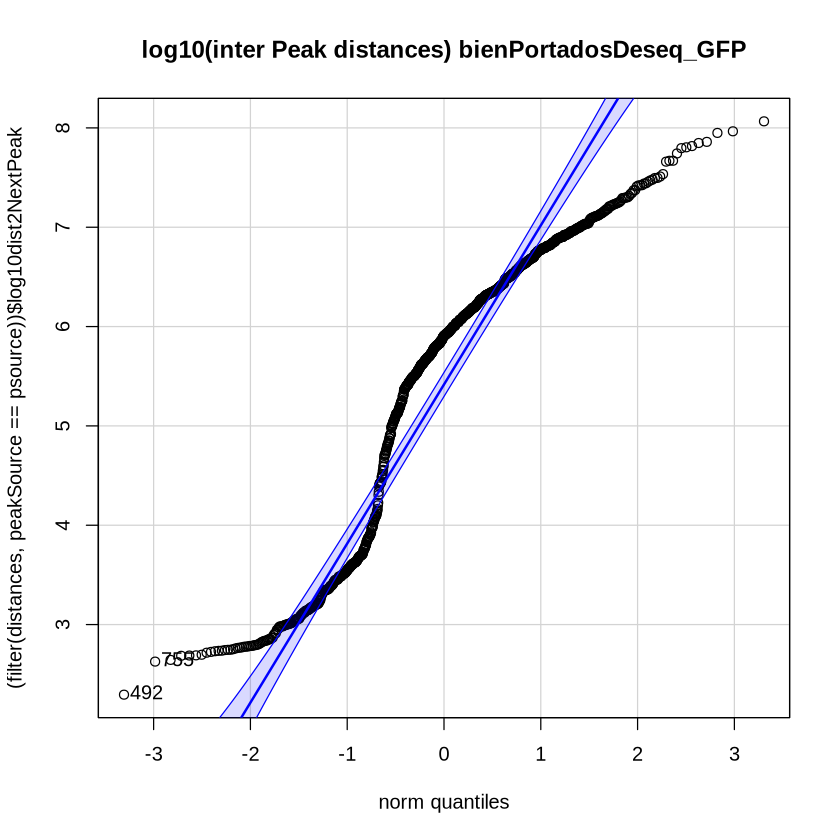

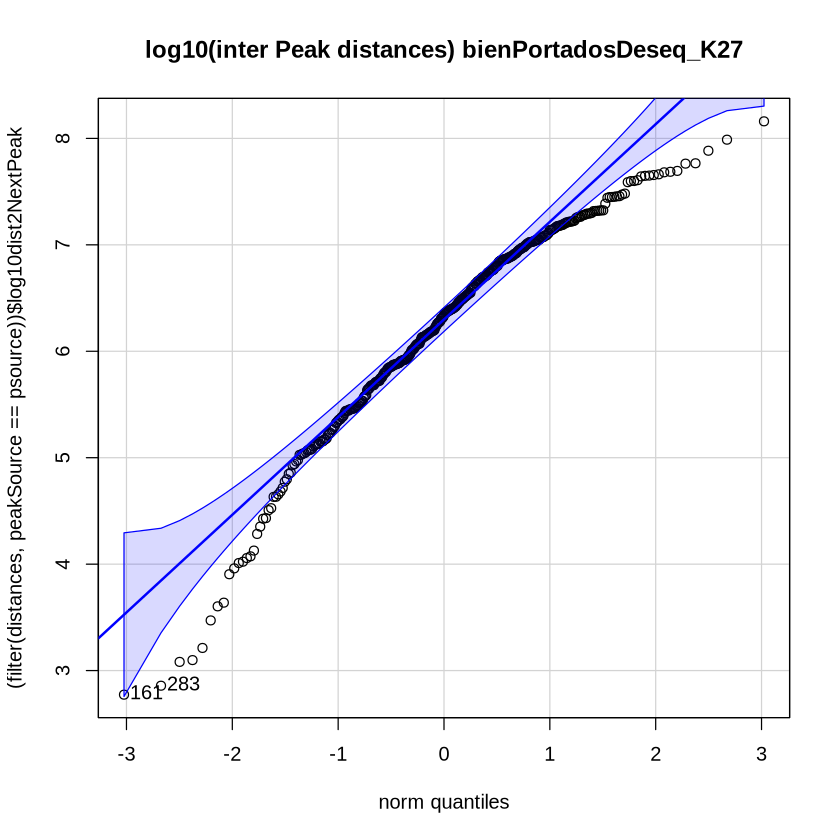

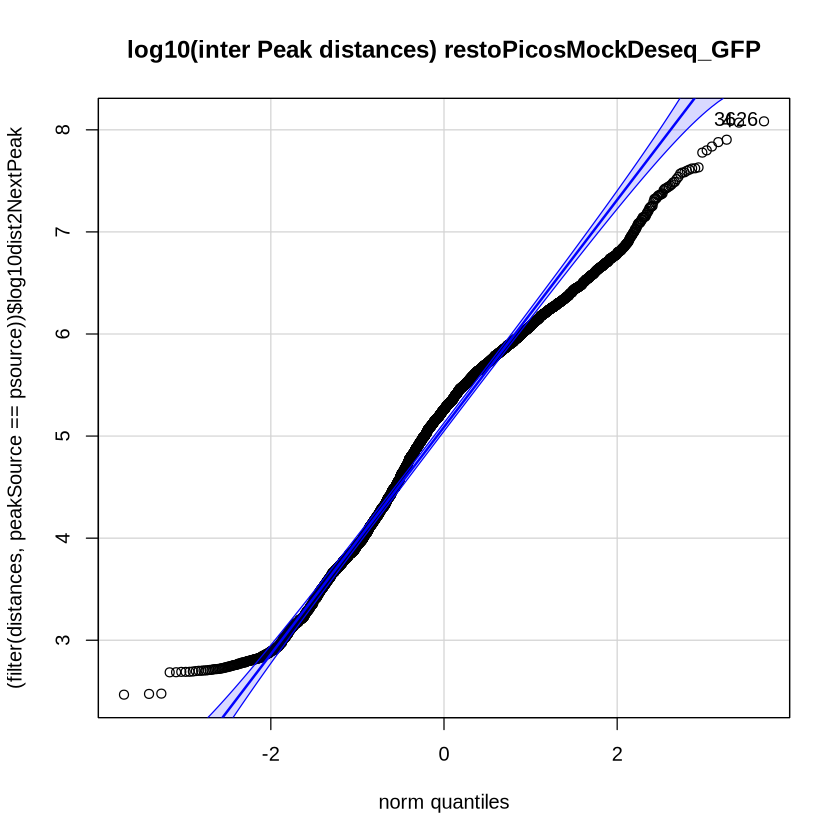

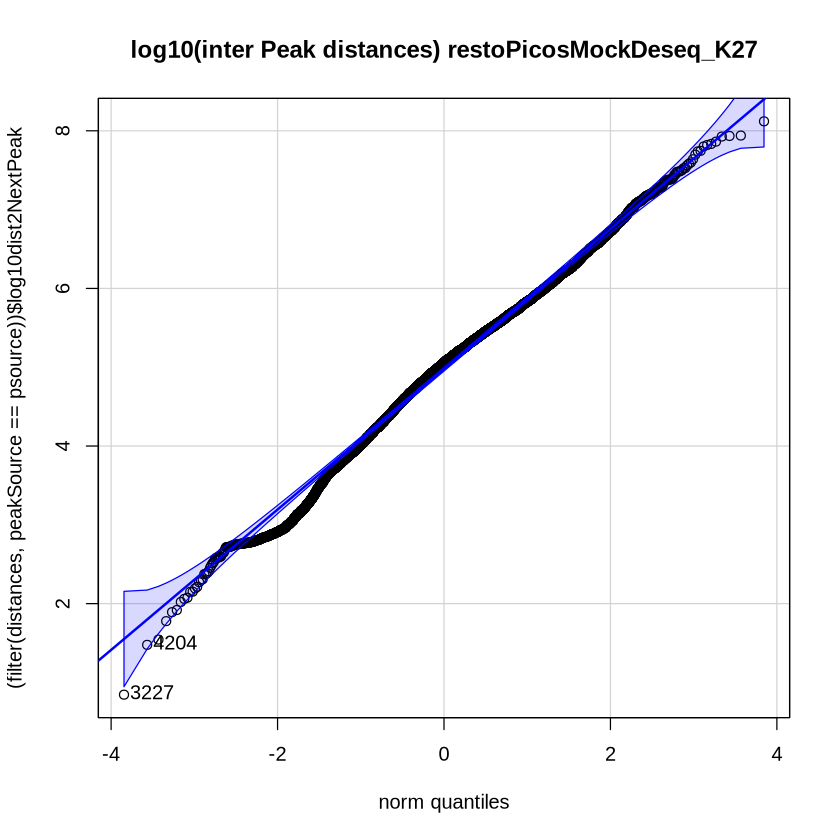

In [7]:
for(psource in pSources){
    qqPlot((distances |> filter(peakSource == psource))$log10dist2NextPeak, main=paste("log10(inter Peak distances)", psource))
}

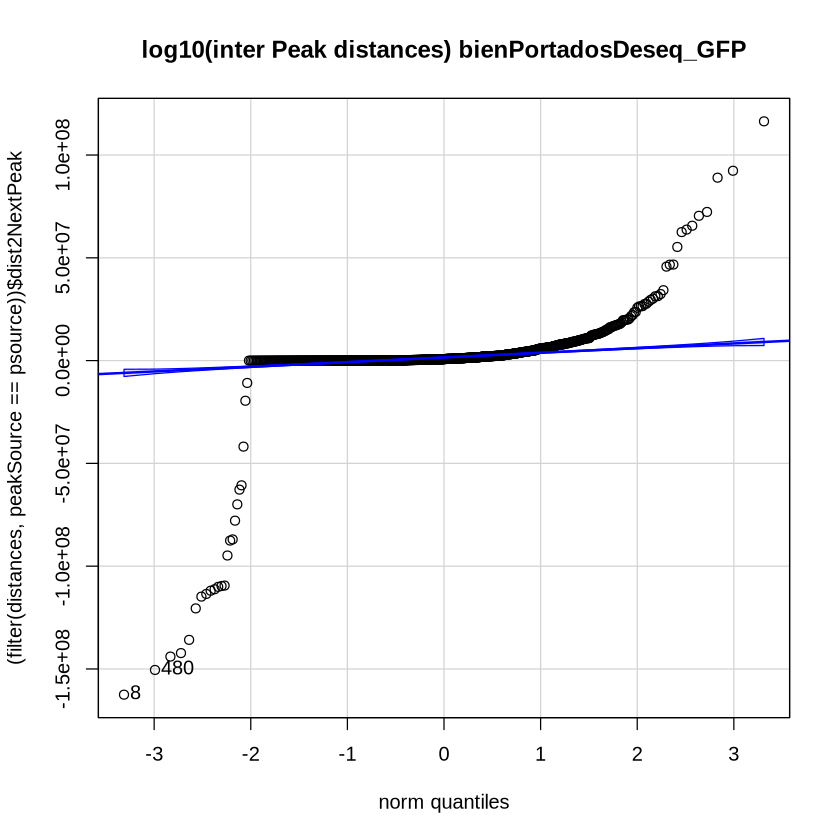

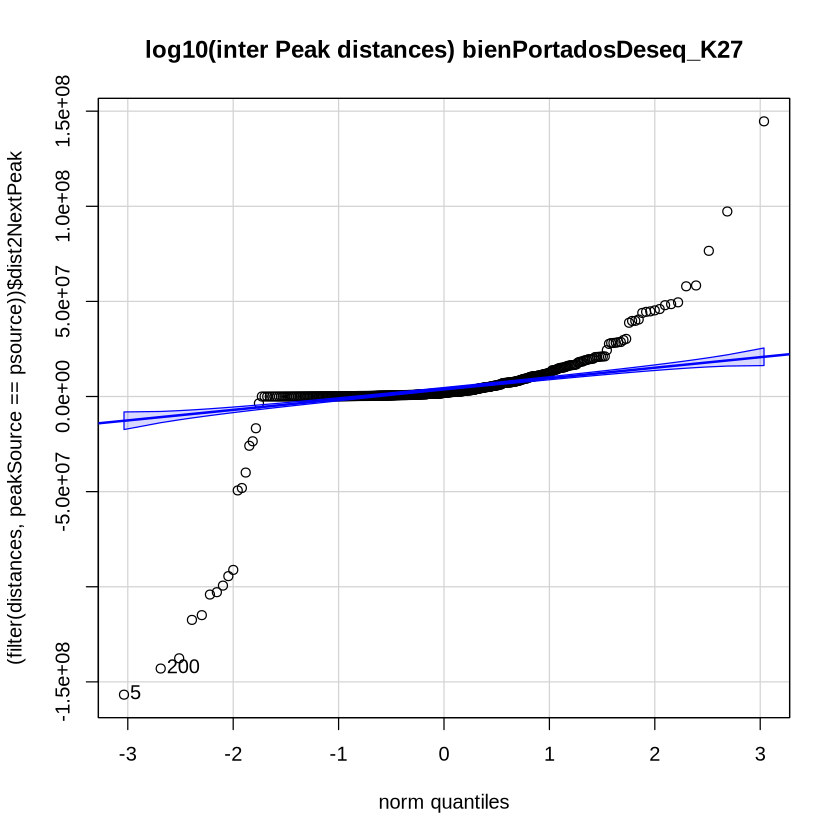

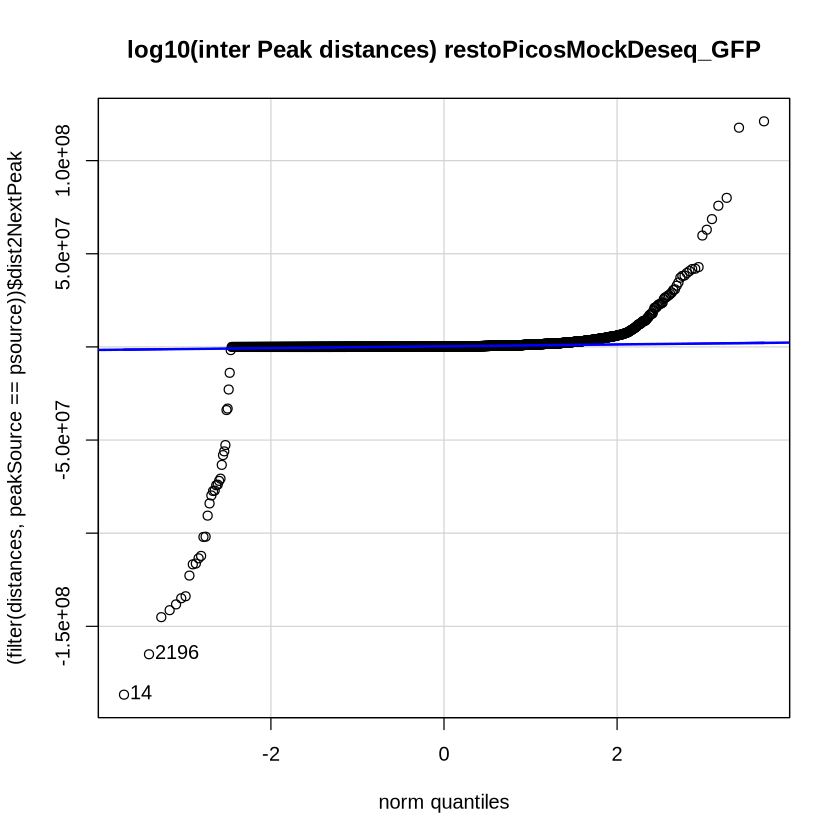

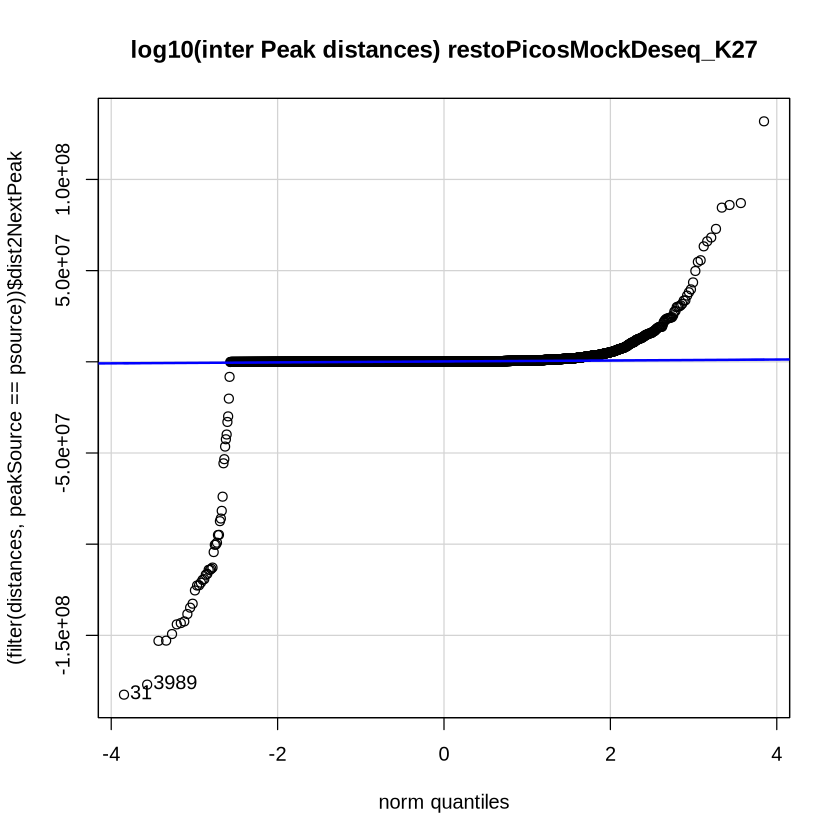

In [8]:
for(psource in pSources){
    qqPlot((distances |> filter(peakSource == psource))$dist2NextPeak, main=paste("log10(inter Peak distances)", psource))
}

Warning message:
“Removed 55 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 55 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 55 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 55 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 60 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 60 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 60 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 60 rows containing non-finite outside the scale range (`stat_boxplot()`).”


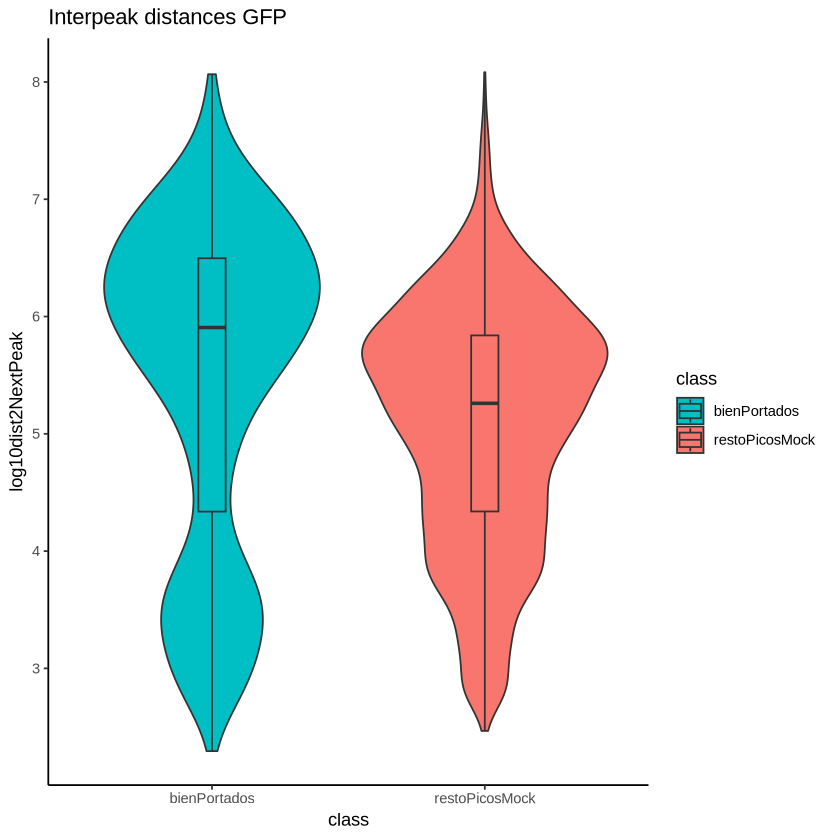

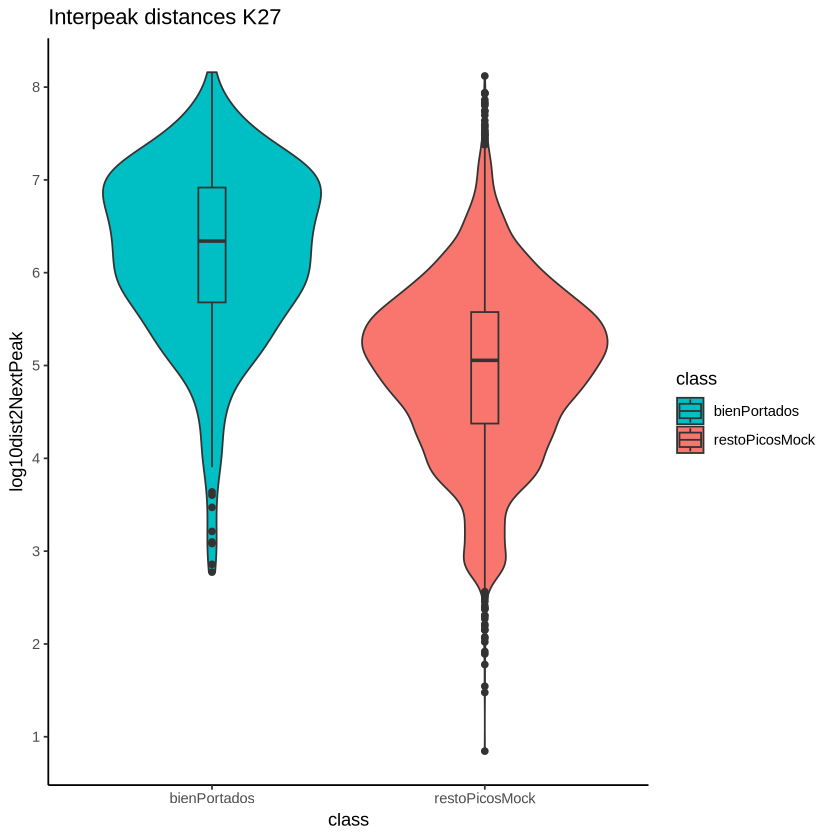

In [10]:
for(chip in unique(distances$ip)){
    df <- distances |> filter(ip == chip)
    plt <- ggplot (df, aes (x = class, y = log10dist2NextPeak, fill = class ))+
        geom_violin()+
        geom_boxplot(width= 0.1)+
        ggtitle(paste("Interpeak distances",chip)) + 
        scale_fill_manual(values = c("bienPortados" = "#00bfc4", "restoPicosMock" = "#f8766d" )) +
        scale_y_continuous(n.breaks = 8) +
        theme_classic()
     pdf(paste0("/hdd/Itzel/NuevoTodo/plotsJul2025/Interpeak_distances_",chip,".pdf"), width = 8 , height = 8)
     print(plt)
     dev.off()
     print(plt)
}

In [ ]:
for(chip in unique(distances$ip)){
    df <- distances |> filter(ip == chip)
    print(ggplot (df, aes (x = class, y = dist2NextPeak, fill = class ))+
        geom_violin()+
        geom_boxplot(width= 0.1)+
        ggtitle(paste("Interpeak distances",chip))
          )
}

In [ ]:
mtxl <- list()
idx <- 1
for(ps in pSources){
    tdf <- distances |> filter(peakSource == ps)
    mtx <- as.matrix(tdf$dist2NextPeak)
    rownames(mtx) <- tdf$id
    colnames(mtx)<-"interPeak Distances"
    mtxl[[idx]]<- mtx
    idx <- idx +1
}
names(mtxl)<-pSources

In [ ]:
glimpse(mtxl)

In [ ]:
bp<-mtxl[[1]]
print(pSources[1])
otsuPlot(bp)
bpcer<-otsuFilterDown(bp)
bplej<-otsuFilterUp(bp)

In [ ]:
resto<-mtxl[[3]]
print(pSources[3])
otsuPlot(resto)
restocer<-otsuFilterDown(resto)
restolej<-otsuFilterUp(resto)

In [ ]:
head(restocer)
head(restolej)
head(bpcer)
head(bplej)

In [ ]:
gfp<- distances |> filter(ip == 'GFP') |> mutate(otsuclass = case_when(id %in% bpcer ~ "Nucleation Near",
                                                                       id %in% bplej ~ "Nucleation Far",
                                                                       id %in% restocer ~ "Other Near",
                                                                       id %in% restolej ~ "Other Far",
                                                                       .default = "Unknown"
                                                                      ))
table(gfp$otsuclass)

In [ ]:
bpcerpicosid <- unique(c(gfp$p1id[gfp$otsuclass == "Nucleation Near"],gfp$p2id[gfp$otsuclass == "Nucleation Near"]))
bplejpicosid <- unique(c(gfp$p1id[gfp$otsuclass == "Nucleation Far"],gfp$p2id[gfp$otsuclass == "Nucleation Far"]))
restocerpicosid <- unique(c(gfp$p1id[gfp$otsuclass == "Other Near"],gfp$p2id[gfp$otsuclass == "Other Near"]))
restolejpicosid <- unique(c(gfp$p1id[gfp$otsuclass == "Other Far"],gfp$p2id[gfp$otsuclass == "Other Far"]))

write(bpcerpicosid,"./distancias_entre_picos_con_deseq_45/bpcerca.txt")
write(bplejpicosid,"./distancias_entre_picos_con_deseq_45/bplejos.txt")
write(restolejpicosid,"./distancias_entre_picos_con_deseq_45/restolejos.txt")
write(restocerpicosid,"./distancias_entre_picos_con_deseq_45/restocerca.txt")

In [ ]:
bplejpicosidfilt <- bplejpicosid[!(bplejpicosid %in% bpcerpicosid)]
restolejpicosidfilt <- restolejpicosid[!(restolejpicosid %in% restocerpicosid)]
write(bplejpicosidfilt,"./distancias_entre_picos_con_deseq_45/bpSoloLejos.txt")
write(restolejpicosidfilt,"./distancias_entre_picos_con_deseq_45/restoSoloLejos.txt")

In [ ]:
bpbed <- read_tsv("./bienPortadosDeseq_bed_41/bienPortadosDeseq_GFP.bed", col_names = F)
restobed <- read_tsv("./bienPortadosDeseq_bed_41/restoPicosMockDeseq_GFP.bed", col_names = F)
bpbed$class <- "Nucleation"
restobed$class <-"Other"
allbed <- rbind(bpbed,restobed)
allbed$size <- allbed$X3 - allbed$X2
allbed <- allbed |> mutate(distanceClass = case_when(X4 %in% bpcerpicosid ~ "Nucleation Near",
                                                     X4 %in% bplejpicosidfilt ~ "Nucleation Far",
                                                     X4 %in% restocerpicosid ~ "Other Near",
                                                     X4 %in% restolejpicosidfilt ~ "Other Far",
                                                     .default = "Unknown"
                                                    )) |> filter(distanceClass != "Unknown")
glimpse(allbed)

In [ ]:
plt <- ggplot(allbed, aes(x=distanceClass, y = size,  fill  = class)) +
geom_boxplot() +
ggtitle ("Length (bp) of peaks by class")+
scale_fill_manual(values = c("Nucleation" = "#00bfc4", "Other" = "#f8766d" )) +
theme_classic()

plt

ggsave("/hdd/Itzel/NuevoTodo/plotsJul2025/lenght_of_peaks_4_classes.pdf", plot = plt, height = 8 , width = 8)


In [ ]:
plt <- ggplot(allbed, aes(x=class, y = size,  fill  = class)) +
geom_boxplot() +
ggtitle ("Length (bp) of peaks by class") + 
scale_fill_manual(values = c("Nucleation" = "#00bfc4", "Other" = "#f8766d" )) +
theme_classic()

plt

ggsave("/hdd/Itzel/NuevoTodo/plotsJul2025/lenght_of_peaks_2_classes.pdf", plot = plt, height = 8 , width = 8)

In [ ]:
write_tsv(allbed,"./motifs_bienPortadosDeseq_ByDistanceClass_homer_46/allPeaks.tsv",col_names = F)

In [ ]:
bpcercasize <- (allbed |> filter(distanceClass == "Nucleation Near"))$size
bplejossize <- (allbed |> filter(distanceClass == "Nucleation Far"))$size
othersize <- (allbed |> filter(class == "Nucleation"))$size
bpsize <- (allbed |> filter(class == "Other"))$size
othercercasize <- (allbed |> filter(distanceClass == "Other Near"))$size
otherlejossize <- (allbed |> filter(distanceClass == "Other Far"))$size

print("Wilcoxon tamaño de picos |  bienportados cercanos vs  bienportados lejanos")
wilcox.test(bpcercasize, bplejossize)
print("---------------------------------------------------------------------------")
print("Wilcoxon tamaño de picos |  bienportados vs resto")
wilcox.test(bpsize, othersize)
print("---------------------------------------------------------------------------")
print("Wilcoxon tamaño de picos |  resto cercanos vs resto lejanos")
wilcox.test(othercercasize,otherlejossize)


In [ ]:
annotab <- read_tsv("./deseq2_supportFiles_40/allPeaks_GFP_Annotated.tsv")

In [ ]:
bpcercasizeAnno <- annotab |> filter(mockPeak_1 %in% bpcerpicosid)
bplejossizeAnno <- annotab |> filter(mockPeak_1 %in% bplejpicosidfilt)

write_tsv(bpcercasizeAnno,"distancias_entre_picos_con_deseq_45/nucleationNearGFP_annotated.tsv")
write_tsv(bplejossizeAnno,"distancias_entre_picos_con_deseq_45/nucleationFarGFP_annotated.tsv")

In [ ]:
table(table(bpcercasizeAnno$geneName))

In [ ]:
table(table(bplejossizeAnno$geneName))

In [ ]:
colnames(allbed) <- c("seq", "start", "end", "id", "class", "size", "distanceClass")
head(allbed)

In [ ]:
table(allbed$class, allbed$distanceClass)

In [ ]:
allbed |> group_by(class) |> summarise(media_size = mean(size))

In [ ]:
allbed |> group_by(distanceClass) |> summarise(media_size = mean(size))

In [ ]:
distgfp <- distances |> filter(ip == 'GFP')
glimpse(distgfp)

In [ ]:
table(distgfp$peakSource)

In [ ]:
distgfp |> group_by(peakSource) |> summarise(mean_dist= mean(dist2NextPeak))

In [ ]:
bp